## Import Required Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Hide unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [3]:
# File names - change these if your files are named differently
PRODUCTS_FILE = 'data/amazon_products.csv'
CATEGORIES_FILE = 'data/amazon_categories.csv'
RATINGS_FILE = 'data/amazon_ratings_electronics.csv'

# Load product data
products_df = pd.read_csv(PRODUCTS_FILE)

# Load category data
categories_df = pd.read_csv(CATEGORIES_FILE)

# Check size of each dataset
print("Products shape:", products_df.shape)
print("Categories shape:", categories_df.shape)

# Check column names - compare this with expected columns below
print("\nProduct columns found:", list(products_df.columns))
print("Category columns found:", list(categories_df.columns))

# Expected columns (verify your actual output matches this)
print("\n Expected product columns: asin, title, imgUrl, price, listPrice, stars, reviews, category_id, isBestSeller")
print("Expected category columns: id, category_name")

Products shape: (1426337, 11)
Categories shape: (248, 2)

Product columns found: ['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price', 'listPrice', 'category_id', 'isBestSeller', 'boughtInLastMonth']
Category columns found: ['id', 'category_name']

 Expected product columns: asin, title, imgUrl, price, listPrice, stars, reviews, category_id, isBestSeller
Expected category columns: id, category_name


## Merge Product and Category Datasets

In [4]:
# Join products with categories using category_id
merged_df = products_df.merge(
    categories_df,
    left_on='category_id',
    right_on='id',
    how='left'
)

# Remove the extra 'id' column (duplicate of category_id)
# Also remove boughtInLastMonth (not needed) and productURL (not needed for our models)
merged_df = merged_df.drop(columns=['id', 'boughtInLastMonth', 'productURL'])

# Check the merge worked correctly
print("Merged shape:", merged_df.shape)
merged_df[['asin', 'title', 'category_id', 'category_name']].head()

Merged shape: (1426337, 10)


,asin,title,category_id,category_name
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",104,Suitcases
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,104,Suitcases
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,104,Suitcases
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,104,Suitcases
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,104,Suitcases


In [5]:
# Check data types and missing values overview
merged_df.info()

# Statistical summary of numeric columns
merged_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1426337 entries, 0 to 1426336
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   asin           1426337 non-null  str    
 1   title          1426336 non-null  str    
 2   imgUrl         1426337 non-null  str    
 3   stars          1426337 non-null  float64
 4   reviews        1426337 non-null  int64  
 5   price          1426337 non-null  float64
 6   listPrice      1426337 non-null  float64
 7   category_id    1426337 non-null  int64  
 8   isBestSeller   1426337 non-null  bool   
 9   category_name  1426337 non-null  str    
dtypes: bool(1), float64(3), int64(2), str(4)
memory usage: 391.5 MB


,stars,reviews,price,listPrice,category_id
count,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06
mean,3.999512e+00,1.807508e+02,4.337540e+01,1.244916e+01,1.237409e+02
std,1.344292e+00,1.761453e+03,1.302893e+02,4.611198e+01,7.311273e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,4.100000e+00,0.000000e+00,1.199000e+01,0.000000e+00,6.500000e+01
50%,4.400000e+00,0.000000e+00,1.995000e+01,0.000000e+00,1.200000e+02
75%,4.600000e+00,0.000000e+00,3.599000e+01,0.000000e+00,1.760000e+02
max,5.000000e+00,3.465630e+05,1.973181e+04,9.999900e+02,2.700000e+02


In [6]:
# Look at first 5 rows
merged_df.head()

,asin,title,imgUrl,stars,reviews,price,listPrice,category_id,isBestSeller,category_name
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,4.5,0,139.99,0.00,104,False,Suitcases
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,4.5,0,169.99,209.99,104,False,Suitcases
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,4.6,0,365.49,429.99,104,False,Suitcases
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,4.6,0,291.59,354.37,104,False,Suitcases
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,4.5,0,174.99,309.99,104,False,Suitcases


## Missing Value Analysis

In [7]:
# Count missing values
missing = merged_df.isnull().sum()

# Convert into table
missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": (missing / len(merged_df) * 100).round(2)
})

# Show only columns having missing values
missing_table = missing_table[missing_table["Missing Count"] > 0]

# Sort highest missing first
missing_table.sort_values("Missing Percent", ascending=False)

,Missing Count,Missing Percent
title,1,0.0


## Duplicate Removal

In [8]:
# Check how many duplicate products exist (same asin repeated)
duplicate_count = merged_df.duplicated(subset=['asin']).sum()
print("Duplicate products found:", duplicate_count)

# Keep only the first copy of each duplicate
merged_df = merged_df.drop_duplicates(subset=['asin'], keep='first')

print("Shape after removing duplicates:", merged_df.shape)

Duplicate products found: 0
Shape after removing duplicates: (1426337, 10)


## Data Cleaning

In [9]:
# Remove rows where title or price is missing
merged_df = merged_df.dropna(subset=['title', 'price'])

# Fill missing review count with 0
merged_df['reviews'] = merged_df['reviews'].fillna(0)

# Fill missing rating with 0
merged_df['stars'] = merged_df['stars'].fillna(0)

# Fill missing bestseller flag with False, then convert to boolean
merged_df['isBestSeller'] = merged_df['isBestSeller'].fillna(False)
merged_df['isBestSeller'] = merged_df['isBestSeller'].astype(bool)

# Fill missing category name with 'Unknown'
merged_df['category_name'] = merged_df['category_name'].fillna('Unknown')

# Remove rows with invalid price
merged_df = merged_df[merged_df['price'] > 0]

print("Shape after cleaning:", merged_df.shape)
print("\nRemaining missing values:")
print(merged_df.isnull().sum())

Shape after cleaning: (1393564, 10)

Remaining missing values:
asin             0
title            0
imgUrl           0
stars            0
reviews          0
price            0
listPrice        0
category_id      0
isBestSeller     0
category_name    0
dtype: int64


## Feature Engineering

In [10]:
# Step 1:Convert review counts into log scale
merged_df["reviews_log"] = np.log1p(merged_df["reviews"])

# Normalize ratings (0 to 1)
merged_df["stars_norm"] = merged_df["stars"] / 5

# Normalize review counts (0 to 1)
merged_df["reviews_norm"] = (
    merged_df["reviews_log"] /
    merged_df["reviews_log"].max()
)

# Bestseller becomes 1 or 0
merged_df["bestseller_score"] = merged_df["isBestSeller"].astype(int)

# Calculate popularity score
merged_df["popularity_score"] = (
      0.5 * merged_df["stars_norm"]
    + 0.4 * merged_df["reviews_norm"]
    + 0.1 * merged_df["bestseller_score"]
)

# Step 2: Discount percentage
merged_df['discount_percent'] = np.where(
    merged_df['listPrice'] > merged_df['price'],
    ((merged_df['listPrice'] - merged_df['price']) / merged_df['listPrice']) * 100,
    0
)

# Step 3: Combined text feature for Content-Based Filtering
merged_df['combined_text'] = merged_df['title'].astype(str) + ' ' + merged_df['category_name'].astype(str)

print("New features created successfully")
merged_df[['title', 'popularity_score', 'discount_percent']].head()

New features created successfully


,title,popularity_score,discount_percent
0,"Sion Softside Expandable Roller Luggage, Black...",0.45,0.000000
1,Luggage Sets Expandable PC+ABS Durable Suitcas...,0.45,19.048526
2,Platinum Elite Softside Expandable Checked Lug...,0.46,15.000349
3,Freeform Hardside Expandable with Double Spinn...,0.46,17.715947
4,Winfield 2 Hardside Expandable Luggage with Sp...,0.45,43.549792


## Select Top 100,000 Products

In [11]:
TARGET_SIZE = 100000

# Load ratings dataset
ratings_df = pd.read_csv(
    RATINGS_FILE,
    names=["user_id", "asin", "rating", "timestamp"]
)

# Products available for collaborative filtering
cf_asins = set(ratings_df["asin"])

# Keep those products first
cf_products = merged_df[
    merged_df["asin"].isin(cf_asins)
]

print("CF Products:", len(cf_products))

# Remaining products
other_products = merged_df[
    ~merged_df["asin"].isin(cf_asins)
]

# Sort remaining by popularity
other_products = other_products.sort_values(
    "popularity_score",
    ascending=False
)

# Number of remaining products needed
remaining = TARGET_SIZE - len(cf_products)

# Select top popular products
top_products = other_products.head(remaining)

# Combine both datasets
top_100k_df = pd.concat(
    [cf_products, top_products],
    ignore_index=True
)

print(top_100k_df.shape)

CF Products: 3721
(100000, 17)


## Exploratory Data Analysis (Visualization)
Rating Distribution

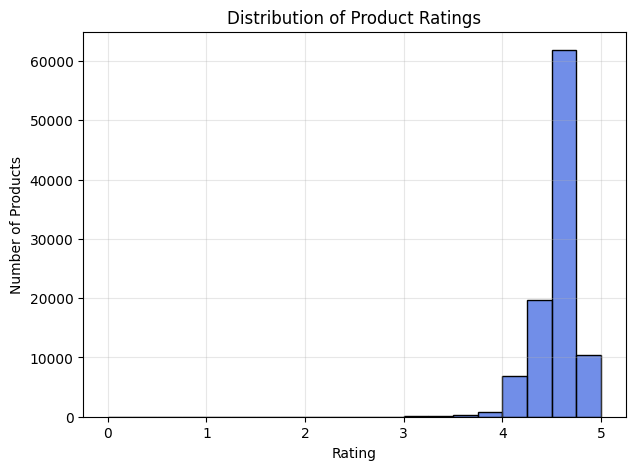

In [13]:
# Distribution of Product Ratings

plt.figure(figsize=(7,5))

sns.histplot(
    data=top_100k_df,
    x="stars",
    bins=20,
    color="royalblue"
)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.grid(alpha=0.3)

plt.show()

Price Distribution

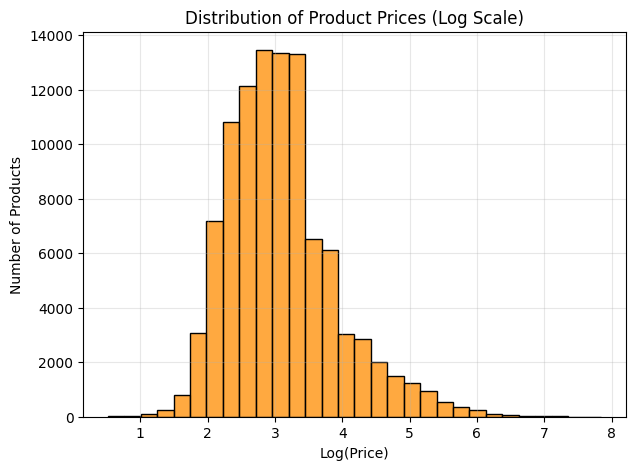

In [15]:
# Product Price Distribution (Log Scale)

plt.figure(figsize=(7,5))

sns.histplot(
    np.log1p(top_100k_df["price"]),
    bins=30,
    color="darkorange"
)

plt.title("Distribution of Product Prices (Log Scale)")
plt.xlabel("Log(Price)")
plt.ylabel("Number of Products")
plt.grid(alpha=0.3)

plt.show()

Top 10 Product Categories

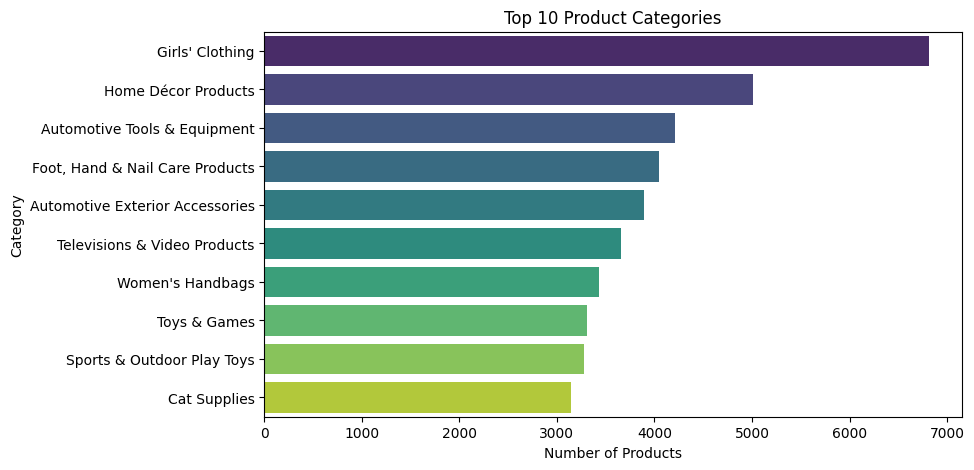

In [16]:
# Top 10 Categories

top_categories = (
    top_100k_df["category_name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    hue=top_categories.index,
    legend=False,
    palette="viridis"
)

plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.show()

### Popularity Score Distribution
Popularity score combines ratings, reviews, and bestseller status into a single metric.

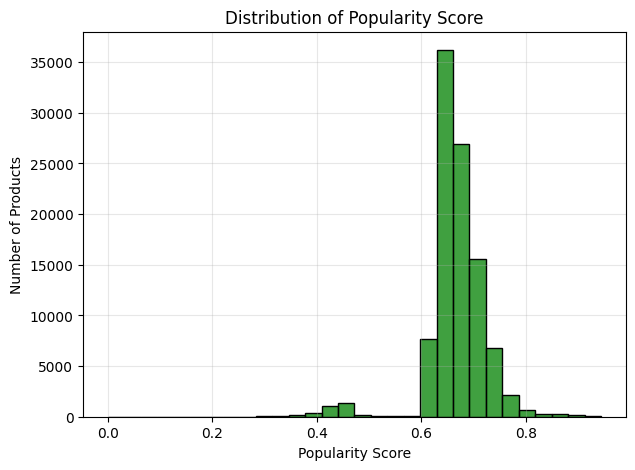

In [17]:
# Popularity Score Distribution

plt.figure(figsize=(7,5))

sns.histplot(
    data=top_100k_df,
    x="popularity_score",
    bins=30,
    color="green"
)

plt.title("Distribution of Popularity Score")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Products")
plt.grid(alpha=0.3)

plt.show()

Reviews vs Ratings

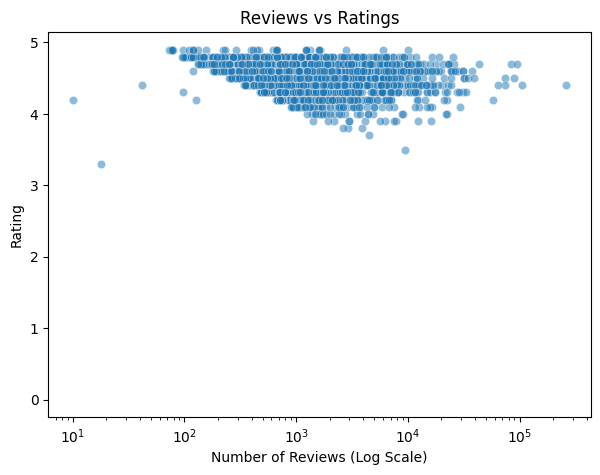

In [19]:
# Relationship between Reviews and Ratings

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=top_100k_df.sample(3000, random_state=42),
    x="reviews",
    y="stars",
    alpha=0.5
)

plt.xscale("log")

plt.title("Reviews vs Ratings")
plt.xlabel("Number of Reviews (Log Scale)")
plt.ylabel("Rating")

plt.show()

## Save Final Clean Dataset

In [20]:
final_columns = [
    'asin', 'title', 'imgUrl', 'category_name', 'price', 'listPrice',
    'stars', 'reviews', 'isBestSeller', 'popularity_score',
    'discount_percent', 'combined_text'
]

clean_df = top_100k_df[final_columns]
clean_df.to_csv('data/clean_amazon_products.csv', index=False)

print("Saved clean_amazon_products.csv with shape:", clean_df.shape)

Saved clean_amazon_products.csv with shape: (100000, 12)


In [21]:
# Verify Display Columns

display_columns = ['asin', 'title', 'imgUrl', 'category_name', 'stars', 'reviews', 'price']

missing_cols = [col for col in display_columns if col not in clean_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All display columns present. Sample output:")

recommendation_display_df = clean_df[display_columns].copy()
recommendation_display_df.head()

All display columns present. Sample output:


,asin,title,imgUrl,category_name,stars,reviews,price
0,B00870XPOI,White Cowhide Sporran,https://m.media-amazon.com/images/I/61EKgDigOG...,Men's Clothing,4.2,0,16.47
1,B000PT18OS,Power Supply 203W AC Adapter XBOX 360 Compatib...,https://m.media-amazon.com/images/I/71E-XR7+Gi...,"Xbox 360 Games, Consoles & Accessories",4.3,0,59.41
2,B000B6MLPU,Microsoft Xbox 360 Component HD AV Cable,https://m.media-amazon.com/images/I/51nlGL+wM1...,"Xbox 360 Games, Consoles & Accessories",4.3,0,9.99
3,B00ICOP4DY,Fosmon 2X Replacement Dongle USB Breakaway Cab...,https://m.media-amazon.com/images/I/61IPAOMMBU...,"Xbox 360 Games, Consoles & Accessories",4.6,0,7.99
4,B002BSH9JY,Halo Reach,https://m.media-amazon.com/images/I/710pquWbf5...,"Xbox 360 Games, Consoles & Accessories",4.3,0,42.70
